In [1]:
%matplotlib inline  

In [1]:
import torch, mindspore, paddle
from matplotlib import pyplot as plt
import numpy as np 
plt.rcParams['font.sans-serif'] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False

- query      查询(自主性提示、意志线索) 
- key        键(非自主性提示、非意志线索)
- value      值(感官、感觉输入)        
- ---> outputs

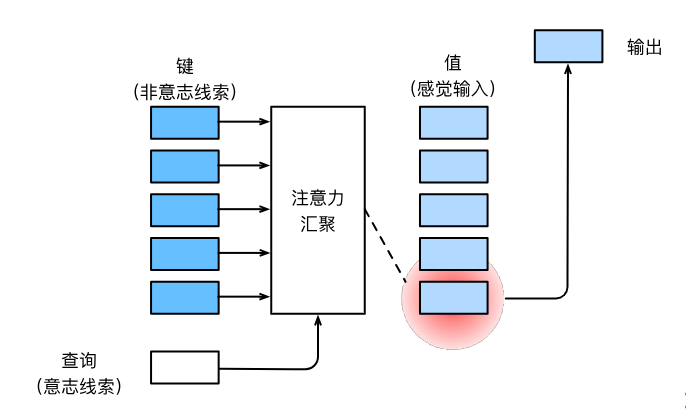

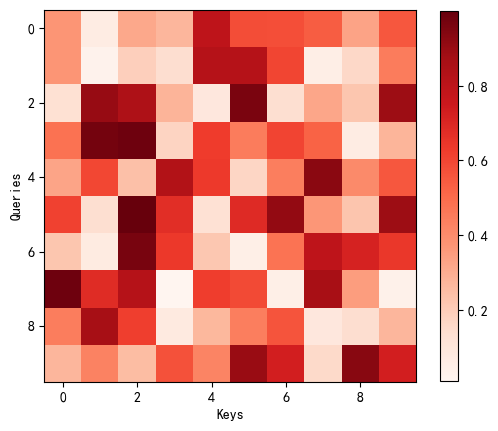

In [4]:
def att_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5), cmap='Reds'):
    """显示矩阵热图"""
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    # 创建子图，确保squeeze=False以保持axes的二维结构
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                             sharex=True, sharey=True, squeeze=False)
    # 遍历所有子图并绘制热图
    for i in range(num_rows):
        for j in range(num_cols):
            ax = axes[i, j]
            matrix = np.asarray(matrices[i, j])  # 转换为numpy数组
            pcm = ax.imshow(matrix, cmap=cmap)
            
            # 只在最下方行显示x轴标签
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            # 只在第一列显示y轴标签
            if j == 0:
                ax.set_ylabel(ylabel)
            # 设置标题（如果提供了titles）
            if titles is not None:
                ax.set_title(titles[j])
    
    # 添加colorbar，使用最后一个子图的pcm对象确定范围
    fig.colorbar(pcm, ax=axes.ravel().tolist(), shrink=0.6)
    plt.show()
    
# 生成示例数据（3行2列的子图，每个热图为4x4矩阵）
matrices = np.random.rand(1, 1, 10, 10)

# 绘制热图
att_heatmaps(matrices, 
              xlabel='Keys',
              ylabel='Queries',
              figsize=(6, 8))
    

In [ ]:
def plot_kernel_reg(y_pred, x_train, x_test, y_train, y_truth):
    # 创建一个新的绘图窗口
    plt.figure(figsize=(4, 3))
    
    # 绘制测试集上的真值和预测值
    plt.plot(x_test, y_truth, label='Truth')
    plt.plot(x_test, y_pred, label='Pred')
    
    # 绘制训练数据（散点图，透明度设置为0.5）
    plt.plot(x_train, y_train, 'o', alpha=0.5)
    
    # 设置坐标轴标签和显示范围
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(0, 5)
    plt.ylim(-1, 5)
    
    # 添加图例
    plt.legend()
    
    # 显示图形
    plt.show()

**注意力汇聚：Nadaraya-Watson核回归**


$\{(x_1, y_1), \ldots, (x_n,y_n)\}$,
$\hat{y}=f(x)$?,
$$y_i=x\sin(x_i)+x_i^{0.8} + \epsilon,$$

**avgmean**:
$$f(x)=\frac{1}{n}\sum_{i=1}^n y_i,$$

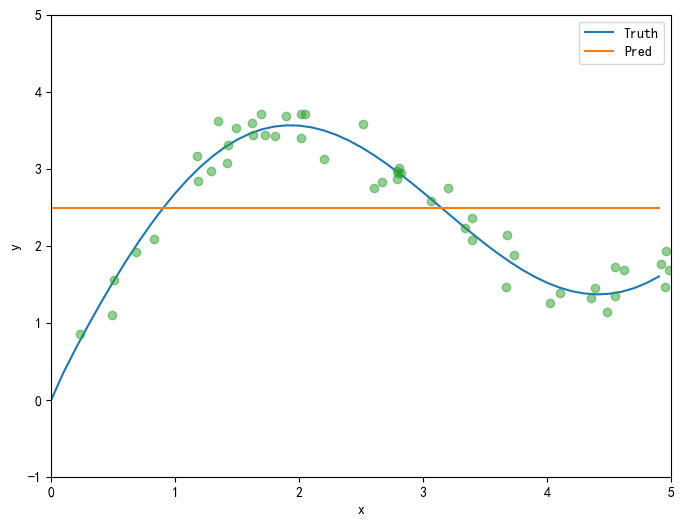

In [ ]:
# 平均汇聚  --跟x无关
num_samples = 50
x_tr, _ = torch.sort(torch.rand(num_samples) * 5, dim=0)
def f(x): return 2*torch.sin(x)+x**0.8
y_tr = f(x_tr) + torch.normal(0.0, 0.2, x_tr.shape)  # + noise
x_te = torch.arange(0, 5, 0.1)
y_truth = f(x_te)   
y_pred = torch.repeat_interleave(y_tr.mean(), num_samples)

plot_kernel_reg(y_pred, x_tr, x_te, y_tr, y_truth)

**raw_fn**:
$$f(x)=\sum_{i=1}^n \frac{K(x-x_i)}{\sum_{j=1}^n K(x-x_j)} y_i,$$

**att_pooling__fn**:
$$f(x)=\sum_{i=1}^n \alpha(x,x_i) y_i,$$

**Gaussian kernel**  nonparametric attention pooling

$$K(u) = \frac{1}{\sqrt{2\pi}} \exp(-\frac{u^2}{2})$$

$$\begin{aligned} f(x) &=\sum_{i=1}^n \alpha(x, x_i) y_i\\ &= \sum_{i=1}^n \frac{\exp\left(-\frac{1}{2}(x - x_i)^2\right)}{\sum_{j=1}^n \exp\left(-\frac{1}{2}(x - x_j)^2\right)} y_i \\&= \sum_{i=1}^n \mathrm{softmax}\left(-\frac{1}{2}(x - x_i)^2\right) y_i. \end{aligned}$$




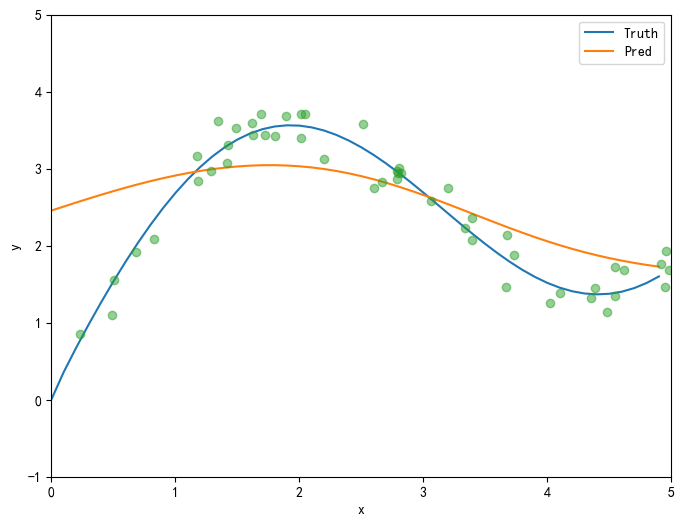

In [24]:
# 非参数的注意力汇聚， Nadaraya-Watson 核回归
x_re = x_te.repeat_interleave(num_samples).reshape((-1,num_samples))
atten_w = torch.nn.functional.softmax(-(x_re-x_tr)**2/2,dim=1) # matrix **2  --dotproduct
y_pred = torch.matmul(atten_w, y_tr)
plot_kernel_reg(y_pred, x_tr, x_te, y_tr, y_truth)

**params-att-pool**

nadaraya-watson-gaussion

$$\begin{aligned}f(x) &= \sum_{i=1}^n \alpha(x, x_i) y_i \\&= \sum_{i=1}^n \frac{\exp\left(-\frac{1}{2}((x - x_i)w)^2\right)}{\sum_{j=1}^n \exp\left(-\frac{1}{2}((x - x_j)w)^2\right)} y_i \\&= \sum_{i=1}^n \mathrm{softmax}\left(-\frac{1}{2}((x - x_i)w)^2\right) y_i.\end{aligned}$$





**批量矩阵乘法**

为了更有效地计算小批量数据的注意力，
我们可以利用深度学习开发框架中提供的批量矩阵乘法。

假设第一个小批量数据包含$n$个矩阵$\mathbf{X}_1,\ldots, \mathbf{X}_n$，
形状为$a\times b$，
第二个小批量包含$n$个矩阵$\mathbf{Y}_1, \ldots, \mathbf{Y}_n$，
形状为$b\times c$。
它们的批量矩阵乘法得到$n$个矩阵
$\mathbf{X}_1\mathbf{Y}_1, \ldots, \mathbf{X}_n\mathbf{Y}_n$，
形状为$a\times c$。
因此，[**假定两个张量的形状分别是$(n,a,b)$和$(n,b,c)$，
它们的批量矩阵乘法输出的形状为$(n,a,c)$**]。

In [6]:
ts_a = torch.ones((2,2,4))
ts_b = torch.ones((2,4,6))
torch.bmm(ts_a,ts_b).shape

torch.Size([2, 2, 6])

In [7]:
weights = torch.ones(2,10) * 0.1
values = torch.arange(20.0).reshape((2,-1))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))  # 2,1,10  bmm 2,10,1 -> 2,1

tensor([[[ 4.5000]],

        [[14.5000]]])

In [8]:
class NWKernelRegression(torch.nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        self.w = torch.nn.Parameter(torch.rand((1,)), requires_grad=True)
    def forward(self, queries, keys, values):
        # queries attention_wrights shape (num_queries, num_KeyValue)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.att_weights = torch.nn.functional.softmax(
            -((queries-keys)*self.w)**2/2, dim=1
        )
        return torch.bmm(self.att_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)        
        

In [ ]:
numsamples = 50
# X_tile的形状:(numsamples,numsamples)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((numsamples, 1))  
print(f"{X_tile.shape = }") # [50, 50]

# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((numsamples, 1))
print(f"{Y_tile.shape = }") # torch.Size([50, 50])

# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(numsamples)).type(torch.bool)].reshape((numsamples, -1))
print(f"{keys = }")
print(f"{keys.shape = }")  # torch.Size([50, 49])

# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(numsamples)).type(torch.bool)].reshape((numsamples, -1))
print(f"{values.shape= }") # torch.Size([50, 49])

X_tile.shape= torch.Size([50, 50])
Y_tile.shape= torch.Size([50, 50])
keys = tensor([[0.1232, 0.2548, 0.3538,  ..., 4.7831, 4.8620, 4.8740],
        [0.0271, 0.2548, 0.3538,  ..., 4.7831, 4.8620, 4.8740],
        [0.0271, 0.1232, 0.3538,  ..., 4.7831, 4.8620, 4.8740],
        ...,
        [0.0271, 0.1232, 0.2548,  ..., 4.7728, 4.8620, 4.8740],
        [0.0271, 0.1232, 0.2548,  ..., 4.7728, 4.7831, 4.8740],
        [0.0271, 0.1232, 0.2548,  ..., 4.7728, 4.7831, 4.8620]])
keys.shape= torch.Size([50, 49])
values.shape= torch.Size([50, 49])


**注意力评分函数**




In [ ]:
import torch.nn as nn
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size，查询的个数，1，num_hidden)
        # key的形状：(batch_size，1，“键－值”对的个数，num_hiddens)
        # 使用广播方式进行求和
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中移除最后那个维度。
        # scores的形状：(batch_size，查询的个数，“键-值”对的个数)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # values的形状：(batch_size，“键－值”对的个数，值的维度)
        return torch.bmm(self.dropout(self.attention_weights), values)   